# ❇️ 데이터 전처리 및 병합

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import copy
from datetime import datetime, timedelta
import random
import warnings

sns.set(font="Malgun Gothic", rc={"axes.unicode_minus": False})  # 마이너스 값 깨지는 거 방지 & 그래프 디자인 배경 회색, 그리드
pd.set_option('display.max_columns', None)  # 전체 출력 O

sellers = pd.read_csv('olist_sellers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
geo = pd.read_csv('olist_geolocation_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_payments = pd.read_csv('olist_order_payments_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
cat_name = pd.read_csv('olist_product_category_name_translation.csv')

# 📚 전처리 함수 정리

#### 1️⃣ `order_items_preprocessed`

In [2]:
def order_items_preprocess(data=order_items):
    '''order_items 전처리 함수
    1. shipping_limit_date -> datetime 타입변환

    - 기본 출력: head(), shape, dtypes, isna().sum()
    - 저장: 데이터명_preprocessed.csv
    '''
    print("="*15, "order_items 전처리 중...", "="*15)
    
    # 1) shipping_limit_date -> datetime 타입변환
    data['shipping_limit_date'] = pd.to_datetime(data['shipping_limit_date'])
    
    print("\n🔎첫 다섯 행 출력")
    display(data.head())
    print("\n🔎(행, 열) 출력")
    print(data.shape)
    print("\n🔎데이터타입 출력")
    print(data.dtypes)
    print("\n🔎컬럼별 결측치 수 출력")
    print(data.isna().sum())

    filename = f"order_items_preprocessed.csv"
    data.to_csv(filename)
    print()
    print(f"✅ {filename} 저장 완료")
    
order_items_preprocess(order_items)

=============== order_items 전처리 중... ===============

🔎첫 다섯 행 출력


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



🔎(행, 열) 출력
(112650, 7)

🔎데이터타입 출력
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

🔎컬럼별 결측치 수 출력
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

✅ order_items_preprocessed.csv 저장 완료


#### 2️⃣ `products_preprocessed`

In [3]:
def products_preprocess(data=products):
    '''products 전처리 함수
    1. 영문 카테고리명 left jon 후 product_category_name_english 결측치 채우기
      - product_category_name에는 있는데 product_category_name_english에는 없는 경우
    2. 나머지 카테고리명 결측치 unknown으로 채우기
    3. ['product_id', 'product_category_name', 'product_category_name_english']만 남기고 다른 컬럼 drop

    - 기본 출력: head(), shape, dtypes, isna().sum()
    - 저장: 데이터명_preprocessed.csv
    '''
    print("="*15, "products 전처리 중...", "="*15)
    products_1 = pd.merge(data, cat_name, how='left', on='product_category_name')

    # 1) 영문 카테고리명 채우기
    products_1.loc[products_1['product_category_name'] == 'pc_gamer', 'product_category_name_english'] = 'pc_gamer'
    products_1.loc[products_1['product_category_name'] == 'portateis_cozinha_e_preparadores_de_alimentos', 'product_category_name_english'] = 'small_kitchen_appliances'
    # 2) 나머지 카테고리명 결측치 unknown으로 채우기
    products_1[['product_category_name', 'product_category_name_english']] = products_1[['product_category_name', 'product_category_name_english']].fillna('unknown')

    print("총 카테고리 수: ", products_1['product_category_name_english'].nunique())
    # 3) 컬럼 drop
    products_2 = products_1[['product_id', 'product_category_name', 'product_category_name_english']]

    print("\n🔎첫 다섯 행 출력")
    display(products_2.head())
    print("\n🔎(행, 열) 출력")
    print(products_2.shape)
    print("\n🔎데이터타입 출력")
    print(products_2.dtypes)
    print("\n🔎컬럼별 결측치 수 출력")
    print(products_2.isna().sum())

    filename = f"products_preprocessed.csv"
    products_2.to_csv(filename)
    print()
    print(f"✅ {filename} 저장 완료")

products_preprocess(products)

=============== products 전처리 중... ===============
총 카테고리 수:  74

🔎첫 다섯 행 출력


,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares



🔎(행, 열) 출력
(32951, 3)

🔎데이터타입 출력
product_id                       object
product_category_name            object
product_category_name_english    object
dtype: object

🔎컬럼별 결측치 수 출력
product_id                       0
product_category_name            0
product_category_name_english    0
dtype: int64

✅ products_preprocessed.csv 저장 완료


#### 3️⃣ `geo_preprocessed`

In [4]:
def geo_preprocess(data=geo):
    '''geolocation 전처리 함수
    1. 도시명 제외, 컬럼들 기준 중복행 제거
    2. 브라질 위도 경도 벗어나는 이상치 주소값 제거
    3. 우편번호별 위도 경도 최빈값을 구해 추후 left join (없으면 가장 첫번째 데이터 추출)

    - 기본 출력: head(), shape, dtypes, isna().sum()
    - 저장: 데이터명_preprocessed.csv
    '''
    print("="*15, "geolocation 전처리 중...", "="*15)
    print("\n🔎중복행 수: ", sum(data[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_state']].duplicated()))

    # 1) 도시명 제외 컬럼들 기준 중복행 제거
    geo_pp = data.drop_duplicates(subset=['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_state'], keep='first')
    print(f"중복 제거 전: {data.shape}")
    print(f"중복 제거 후: {geo_pp.shape}")

    # 2) 브라질 위도 경도 벗어나는 이상치 주소값 제거
    # 브라질 위도 경도 범위
    lat_min, lat_max = -35, 6
    lng_min, lng_max = -75, -32

    geo_clean = geo_pp[
        (geo_pp['geolocation_lat'].between(lat_min, lat_max)) &
        (geo_pp['geolocation_lng'].between(lng_min, lng_max))
    ]

    # 3) 우편번호별 위도 경도 최빈값
    def get_mode(x):
        mode_result = x.mode()
        if not mode_result.empty:
            return mode_result.iloc[0]
        return None

    geo_mode = geo_clean.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].agg(get_mode).reset_index()

    # 컬럼명 변경
    geo_mode.rename(columns={
        'geolocation_lat': 'lat_mode',
        'geolocation_lng': 'lng_mode'
    }, inplace=True)

    geo_unique = geo_clean.drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first')
    geo_unique = geo_unique[['geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state']]

    # 4) 데이터 통합
    geo_full_preprocessed = pd.merge(geo_mode, geo_unique, how='left', on='geolocation_zip_code_prefix')

    print("\n🔎첫 다섯 행 출력")
    display(geo_full_preprocessed.head())
    print("\n🔎(행, 열) 출력")
    print(geo_full_preprocessed.shape)
    print("\n🔎데이터타입 출력")
    print(geo_full_preprocessed.dtypes)
    print("\n🔎컬럼별 결측치 수 출력")
    print(geo_full_preprocessed.isna().sum())

    filename = f"geo_preprocessed.csv"
    geo_full_preprocessed.to_csv(filename)
    print()
    print(f"✅ {filename} 저장 완료")
    
geo_preprocess(geo)


=============== geolocation 전처리 중... ===============

🔎중복행 수:  280007
중복 제거 전: (1000163, 5)
중복 제거 후: (720156, 5)

🔎첫 다섯 행 출력


,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state
0,1001,-23.551427,-46.634410,sao paulo,SP
1,1002,-23.548878,-46.636361,sao paulo,SP
2,1003,-23.549083,-46.637157,sao paulo,SP
3,1004,-23.550765,-46.635371,sao paulo,SP
4,1005,-23.549980,-46.638411,sao paulo,SP



🔎(행, 열) 출력
(19011, 5)

🔎데이터타입 출력
geolocation_zip_code_prefix      int64
lat_mode                       float64
lng_mode                       float64
geolocation_city                object
geolocation_state               object
dtype: object

🔎컬럼별 결측치 수 출력
geolocation_zip_code_prefix    0
lat_mode                       0
lng_mode                       0
geolocation_city               0
geolocation_state              0
dtype: int64

✅ geo_preprocessed.csv 저장 완료


#### 4️⃣ `order_payments_preprocessed`

In [5]:
def order_payments_preprocess(data=order_payments):
    '''order_payments 전처리 함수
    1. payment_type == 'not_defined' 제거
    2. payment_value == 0 제거
    3. payment_installments == 0 제거

    - 기본 출력: head(), shape, dtypes, isna().sum()
    - 저장: 데이터명_preprocessed.csv
    '''
    print("="*15, "order_payments 전처리 중...", "="*15)
    
    # 1) payment_type == 'not_defined' 제거
    mask_not_defined = data["payment_type"] == "not_defined"
    print("not_defined 건수:", mask_not_defined.sum())
    data = data[~mask_not_defined]

    # 2) payment_value == 0 제거
    mask_zero_value = data["payment_value"] == 0
    print("payment_value == 0 건수:", mask_zero_value.sum())
    data = data[~mask_zero_value]

    # 3) payment_installments == 0 제거
    mask_zero_install = data["payment_installments"] == 0
    print("payment_installments == 0 건수:", mask_zero_install.sum())
    data = data[~mask_zero_install]

    print("\n🔎첫 다섯 행 출력")
    display(data.head())
    print("\n🔎(행, 열) 출력")
    print(data.shape)
    print("\n🔎데이터타입 출력")
    print(data.dtypes)
    print("\n🔎컬럼별 결측치 수 출력")
    print(data.isna().sum())

    filename = f"order_payments_preprocessed.csv"
    data.to_csv(filename)
    print()
    print(f"✅ {filename} 저장 완료")

order_payments_preprocess(order_payments)

=============== order_payments 전처리 중... ===============
not_defined 건수: 3
payment_value == 0 건수: 6
payment_installments == 0 건수: 2

🔎첫 다섯 행 출력


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



🔎(행, 열) 출력
(103875, 5)

🔎데이터타입 출력
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

🔎컬럼별 결측치 수 출력
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

✅ order_payments_preprocessed.csv 저장 완료


#### 5️⃣ `orders_preprocessed`

In [6]:
def orders_preprocess(data=orders):
    '''orders 전처리 함수
    1. 'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date' -> datetime 타입변환
    2. payment_value == 0 제거
    3. payment_installments == 0 제거

    - 기본 출력: head(), shape, dtypes, isna().sum()
    - 저장: 데이터명_preprocessed.csv
    '''
    print("="*15, "orders 전처리 중...", "="*15)    

    # 1) datetime 변환
    date_columns = ["order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"]
    data[date_columns] = data[date_columns].apply(pd.to_datetime)
    
    # # 2) 물류전달시간 제거
    # data = data.drop(columns=["order_delivered_carrier_date"])

    # 3) 배송 지연일수 파생 컬럼 생성
    data["delivery_delay_days"] = (
        data["order_delivered_customer_date"] - data["order_estimated_delivery_date"]
    ).dt.days

    # 4) 배송지연여부: 지연O = 1, 지연X = 0
    data["is_delayed"] = (data["delivery_delay_days"] > 0).where(
        data["delivery_delay_days"].notna(),
        other=np.nan
    ).astype("float")

    # 5) 주문취소여부: 취소O = 1, 취소X = 0
    data['is_canceled'] = data['order_status'].apply(lambda x: 1 if x == 'canceled' else 0)

    print("\n🔎배송지연여부 분포")
    print(data['is_delayed'].value_counts())
    print("\n🔎첫 다섯 행 출력")
    display(data.head())
    print("\n🔎(행, 열) 출력")
    print(data.shape)
    print("\n🔎데이터타입 출력")
    print(data.dtypes)
    print("\n🔎컬럼별 결측치 수 출력")
    print(data.isna().sum())

    filename = f"orders_preprocessed.csv"
    data.to_csv(filename)
    print()
    print(f"✅ {filename} 저장 완료")

orders_preprocess(orders)

=============== orders 전처리 중... ===============

🔎배송지연여부 분포
is_delayed
0.0    89941
1.0     6535
Name: count, dtype: int64

🔎첫 다섯 행 출력


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,0.0,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,0.0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,0.0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13.0,0.0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10.0,0.0,0



🔎(행, 열) 출력
(99441, 11)

🔎데이터타입 출력
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
delivery_delay_days                     float64
is_delayed                              float64
is_canceled                               int64
dtype: object

🔎컬럼별 결측치 수 출력
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
delivery_delay_days              2965
is_delayed                       2965
is_canceled                 

#### 6️⃣ `sellers_preprocessed`

In [7]:
import unicodedata
import re

def clean_city_name(city):
    if pd.isna(city):
        return city

    # 1. 소문자로 통일
    city = city.lower()

    # 2. 앞뒤 공백 제거
    city = city.strip()

    # 3. 여러 개의 공백을 하나로 바꾸기
    city = re.sub(r'\s+', ' ', city)

    # 4. 특수문자 제거(문자, 공백만 허용)
    city = re.sub(r'[^a-zA-Z\s]', '', city)

    # 5. 포르투갈어 액센트 제거 (são → sao, curitíba → curitiba)
    # 1) 문자열을 NFD 방식으로 분해
    # 포르투갈어/유럽 언어의 문자들은 “기본 문자 + 결합형 액센트”로 쪼개짐.
    normalized = unicodedata.normalize('NFD', city)

    # 2) 결과를 담을 빈 문자열 생성
    result = ""

    # 3) 분해된 문자들을 하나씩 확인
    for c in normalized:
    # 유니코드 카테고리가 'Mn' = 액센트(결합 부호)
        if unicodedata.category(c) != 'Mn':
        # 액센트가 아닌 글자만 추가
        # 즉, 포르투갈어/유럽 언어가 알파벳과 액센트로 쪼개져서 액센트만 제거 후 result에 추가
            result += c

    # 4) result가 액센트 제거된 문자열
    city = result

    return city


def normalize_known_cities(city):
    """
    실제 Olist 데이터에서 자주 나오는 변형들을 정규화
    -> GPT 도움
    """
    mapping = {
        'sao paulo': ['sao paulo', 'sao  paulo', 'saopaulo', 'san paulo', 's o paulo'],
        'rio de janeiro': ['rio de janeiro', 'rio  de janeiro', 'riodejaneiro'],
        'belo horizonte': ['belo horizonte', 'belo  horizonte'],
        'curitiba': ['curitiba', 'cur itiba'],
        'brasilia': ['brasilia', 'brasilía', 'brasil ia']
    }

    for key, values in mapping.items():
        if city in values:
            return key 
    
    return city

print("☑️ 도시명 전처리 함수 정의 완료!")
print("☑️ 도시명 정규화 함수 정의 완료!")

def sellers_preprocess(data=sellers):
    '''sellers 전처리 함수
    1. 도시명 표준화

    - 기본 출력: head(), shape, dtypes, isna().sum()
    - 저장: 데이터명_preprocessed.csv
    '''
    print("="*15, "sellers 전처리 중...", "="*15)    

    # 표준화 함수 적용
    data['seller_city_clean'] = data['seller_city'].apply(clean_city_name)
    data['seller_city_clean'] = data['seller_city_clean'].apply(normalize_known_cities)

    print("\n🔎첫 다섯 행 출력")
    display(data.head())
    print("\n🔎(행, 열) 출력")
    print(data.shape)
    print("\n🔎데이터타입 출력")
    print(data.dtypes)
    print("\n🔎컬럼별 결측치 수 출력")
    print(data.isna().sum())

    filename = f"sellers_preprocessed.csv"
    data.to_csv(filename)
    print()
    print(f"✅ {filename} 저장 완료")

sellers_preprocess(sellers)

☑️ 도시명 전처리 함수 정의 완료!
☑️ 도시명 정규화 함수 정의 완료!
=============== sellers 전처리 중... ===============

🔎첫 다섯 행 출력


,seller_id,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,campinas
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP,mogi guacu
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ,rio de janeiro
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP,sao paulo
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP,braganca paulista



🔎(행, 열) 출력
(3095, 5)

🔎데이터타입 출력
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
seller_city_clean         object
dtype: object

🔎컬럼별 결측치 수 출력
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
seller_city_clean         0
dtype: int64

✅ sellers_preprocessed.csv 저장 완료


#### 7️⃣ `order_reviews_preprocessed`

In [8]:
def order_reviews_preprocess(data=order_reviews):
    '''sellers 전처리 함수
    1. review_creation_date -> datetime 변환
    2. 주문 건수당 최신 리뷰 한개씩만 남기기

    - 기본 출력: head(), shape, dtypes, isna().sum()
    - 저장: 데이터명_preprocessed.csv
    '''
    print("="*15, "order_reviews 전처리 중...", "="*15)    

    # 1) 문자열 → datetime으로 변환
    data['review_creation_date'] = pd.to_datetime(
        data['review_creation_date']
    )

    # 2) 주문 건수당 최신 리뷰 한개씩만 남기긱
    # order_id별 review_id 개수 세기
    review_counts = data.groupby('order_id')['review_id'].nunique()

    # 2개 이상 리뷰가 있는 order_id 추출
    multi_review_orders = review_counts[review_counts > 1].index

    # 해당 order_id만 필터링
    df_multi = data[data['order_id'].isin(multi_review_orders)]

    # 각 order_id별 최신 리뷰만 선택
    latest_idx = df_multi.groupby('order_id')['review_creation_date'].idxmax()
    latest_reviews = df_multi.loc[latest_idx].sort_values('order_id')

    # 필요한 컬럼만 추출
    latest_reviews_final = latest_reviews[['review_id', 'order_id', 'review_score', 'review_comment_message', 'review_creation_date']]

    # 3) 주문 건수당 하나의 리뷰가 있는 데이터와 concat
    single_review_orders = review_counts[review_counts == 1].index
    df_single = order_reviews[order_reviews['order_id'].isin(single_review_orders)]
    df_single = df_single[['review_id', 'order_id', 'review_score', 'review_comment_message']]

    reviews_preprocessed = pd.concat([df_single, latest_reviews_final]).reset_index().drop(columns=['index'])

    print("\n🔎첫 다섯 행 출력")
    display(reviews_preprocessed.head())
    print("\n🔎(행, 열) 출력")
    print(reviews_preprocessed.shape)
    print("\n🔎데이터타입 출력")
    print(reviews_preprocessed.dtypes)
    print("\n🔎컬럼별 결측치 수 출력")
    print(reviews_preprocessed.isna().sum())

    filename = f"order_reviews_preprocessed.csv"
    reviews_preprocessed.to_csv(filename)
    print()
    print(f"✅ {filename} 저장 완료")

order_reviews_preprocess(order_reviews)

=============== order_reviews 전처리 중... ===============



🔎첫 다섯 행 출력


,review_id,order_id,review_score,review_comment_message,review_creation_date
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaT
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaT
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaT
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.,NaT
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela I...,NaT



🔎(행, 열) 출력
(98673, 5)

🔎데이터타입 출력
review_id                         object
order_id                          object
review_score                       int64
review_comment_message            object
review_creation_date      datetime64[ns]
dtype: object

🔎컬럼별 결측치 수 출력
review_id                     0
order_id                      0
review_score                  0
review_comment_message    57896
review_creation_date      98126
dtype: int64

✅ order_reviews_preprocessed.csv 저장 완료


# 🗃️ 통합(master table) 함수

In [9]:
def merge_all():
    '''
    전처리된 테이블로 master table 만드는 함수
    cf) order_payments는 일단 join하지 않음
    '''
    print("="*15, "master table 만드는 중...", "="*15)    

    order_items_preprocessed = pd.read_csv('order_items_preprocessed.csv', index_col=0)
    products_preprocessed = pd.read_csv('products_preprocessed.csv', index_col=0)
    geo_preprocessed = pd.read_csv('geo_preprocessed.csv', index_col=0)
    orders_preprocessed = pd.read_csv('orders_preprocessed.csv', index_col=0)
    order_reviews_preprocessed = pd.read_csv('order_reviews_preprocessed.csv', index_col=0)
    sellers_preprocessed = pd.read_csv('sellers_preprocessed.csv', index_col=0)
    customers_preprocessed = pd.read_csv('olist_customers_dataset.csv')
    # order_payments_preprocessed = pd.read_csv('order_payments_preprocessed.csv', index_col=0)

    # 1. order_items에 orders를 left join
    df = order_items_preprocessed.merge(orders_preprocessed, on='order_id', how='left')

    # 2. products를 left join
    df = df.merge(products_preprocessed, on='product_id', how='left')

    # 3. sellers를 left join
    df = df.merge(sellers_preprocessed, on='seller_id', how='left')

    # 4. customers를 left join
    df = df.merge(customers_preprocessed, on='customer_id', how='left')

    # 5. reviews를 left join
    df = df.merge(order_reviews_preprocessed, on='order_id', how='left')

    # 6. geolocation을 sellers 기준으로 left join
    df = df.merge(geo_preprocessed, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')

    print("\n🔎첫 다섯 행 출력")
    display(df.head())
    print("\n🔎(행, 열) 출력")
    print(df.shape)
    print("\n🔎컬럼별 결측치 수 출력")
    print(df.isna().sum())

    # 7. 저장
    df.to_csv('merged_df_vF.csv')
    print("✅ merged_df_vF.csv 저장 완료!")
    return df

merge_all()

=============== master table 만드는 중... ===============

🔎첫 다섯 행 출력


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9.0,0.0,0,cool_stuff,cool_stuff,27277,volta redonda,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5.0,"Perfeito, produto entregue antes do combinado.",NaN,27277.0,-22.501227,-44.124864,volta redonda,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3.0,0.0,0,pet_shop,pet_shop,3471,sao paulo,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,3471.0,-23.571687,-46.521540,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14.0,0.0,0,moveis_decoracao,furniture_decor,37564,borda da mata,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,Chegou antes do prazo previsto e o produto sur...,NaN,37564.0,-22.324906,-46.239752,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6.0,0.0,0,perfumaria,perfumery,14403,franca,SP,franca,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,14403.0,-20.545472,-47.381048,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16.0,0.0,0,ferramentas_jardim,garden_tools,87900,loanda,PR,loanda,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,940144190dcba6351888cafa43f3a3a5,5.0,Gostei pois veio no prazo determinado .,NaN,87900.0,-22.939806,-53.148630,loanda,PR



🔎(행, 열) 출력
(112650, 36)

🔎컬럼별 결측치 수 출력
order_id                              0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1194
order_delivered_customer_date      2454
order_estimated_delivery_date         0
delivery_delay_days                2454
is_delayed                         2454
is_canceled                           0
product_category_name                 0
product_category_name_english         0
seller_zip_code_prefix                0
seller_city                           0
seller_state                          0
seller_city_clean                     1
customer_unique_id                    0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9.0,0.0,0,cool_stuff,cool_stuff,27277,volta redonda,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5.0,"Perfeito, produto entregue antes do combinado.",NaN,27277.0,-22.501227,-44.124864,volta redonda,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3.0,0.0,0,pet_shop,pet_shop,3471,sao paulo,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,3471.0,-23.571687,-46.521540,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14.0,0.0,0,moveis_decoracao,furniture_decor,37564,borda da mata,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,Chegou antes do prazo previsto e o produto sur...,NaN,37564.0,-22.324906,-46.239752,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6.0,0.0,0,perfumaria,perfumery,14403,franca,SP,franca,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,14403.0,-20.545472,-47.381048,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16.0,0.0,0,ferramentas_jardim,garden_tools,87900,loanda,PR,loanda,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,940144190dcba6351888cafa43f3a3a5,5.0,Gostei pois veio no prazo determinado .,NaN,87900.0,-22.939806,-53.148630,loanda,PR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,-8.0,0.0,0,utilidades_domesticas,housewares,88303,itajai,SC,itajai,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA,9185f849f32d82e216a4e025e0c50f5c,5.0,NaN,NaN,88303.0,-26.921314,-48.685234,itajai,SC
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04

# ☑️ Segment 기준 탐색 및 파생컬럼 생성
Enterprise / SMB 구분 기준

In [10]:
df = pd.read_csv("merged_df_vF.csv", index_col=0)

# datetime 변환
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'shipping_limit_date',
             'order_delivered_customer_date', 'order_delivered_carrier_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112650 entries, 0 to 112649
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   order_item_id                  112650 non-null  int64         
 2   product_id                     112650 non-null  object        
 3   seller_id                      112650 non-null  object        
 4   shipping_limit_date            112650 non-null  datetime64[ns]
 5   price                          112650 non-null  float64       
 6   freight_value                  112650 non-null  float64       
 7   customer_id                    112650 non-null  object        
 8   order_status                   112650 non-null  object        
 9   order_purchase_timestamp       112650 non-null  datetime64[ns]
 10  order_approved_at              112635 non-null  datetime64[ns]
 11  order

### 1) 퍼센타일 분포

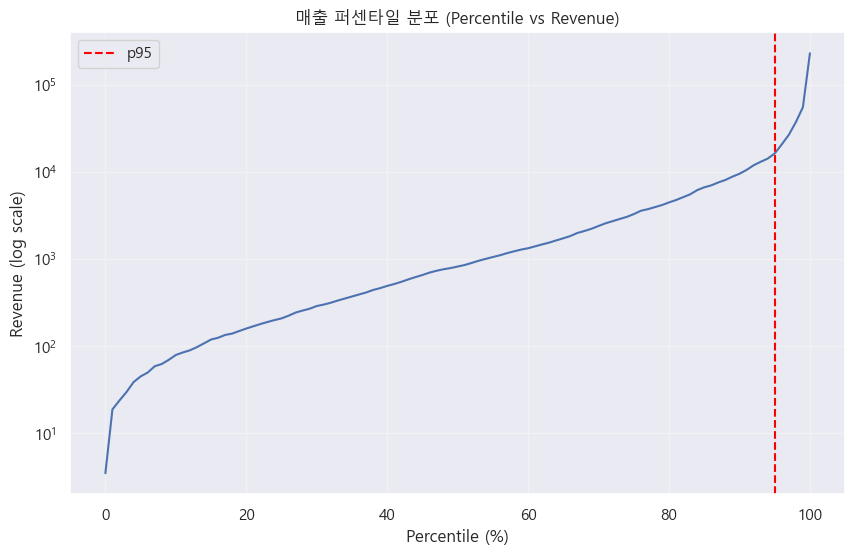

In [11]:
# ----------------------------------
# 매출 퍼센타일 분포
# ----------------------------------
# seller별 매출 unique
seller_total_revenue = df.groupby('seller_id')['price'].sum().reset_index()
seller_total_revenue = seller_total_revenue.rename(columns={'price':'seller_total_revenue'})
rev = seller_total_revenue["seller_total_revenue"]

# 0~100 percentile 계산
percentiles = np.arange(0, 101)
values = np.percentile(rev, percentiles)

plt.figure(figsize=(10,6))
plt.plot(percentiles, values)
plt.axvline(95, color='red', linestyle='--', label='p95')
plt.yscale('log')

plt.title("매출 퍼센타일 분포 (Percentile vs Revenue)")
plt.xlabel("Percentile (%)")
plt.ylabel("Revenue (log scale)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

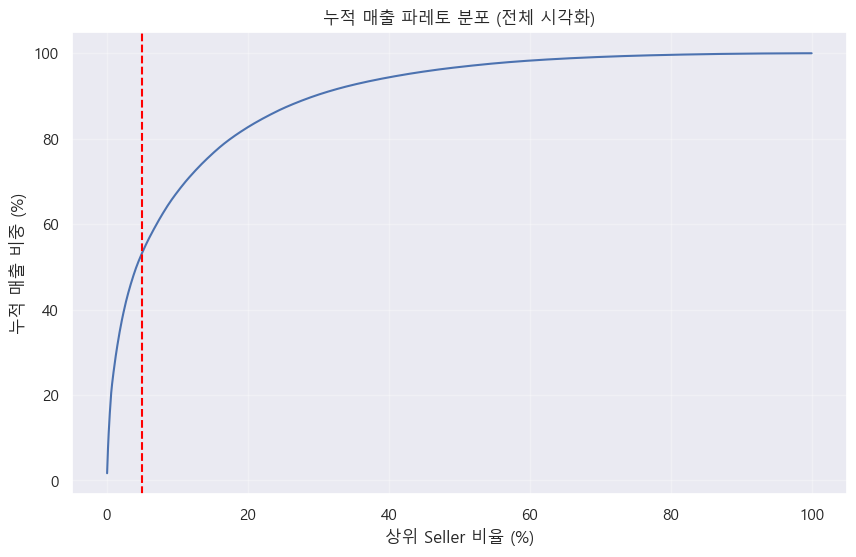

In [12]:
# ----------------------------------
# 누적 매출 파레토 분포
# ----------------------------------
rev_sorted = rev.sort_values(ascending=False).reset_index(drop=True)

cum_share = rev_sorted.cumsum() / rev_sorted.sum()
seller_ratio = (np.arange(1, len(rev_sorted)+1) / len(rev_sorted)) * 100

# 5) 상위 5% 지점 계산
top_5_ratio = 5  # 단순 기준
top_5_index = int(len(rev_sorted) * 0.05) - 1  # 0-index 보정
top_5_cum_share = cum_share[top_5_index] * 100  # 누적매출 %

plt.figure(figsize=(10,6))
plt.plot(seller_ratio, cum_share * 100)
plt.axvline(5, color='red', linestyle='--', label='Top 5%')
plt.title("누적 매출 파레토 분포 (전체 시각화)")
plt.xlabel("상위 Seller 비율 (%)")
plt.ylabel("누적 매출 비중 (%)")
plt.grid(alpha=0.3)
plt.show()

In [13]:
# seller_id별 매출 unique 테이블
seller_total_revenue = df.groupby('seller_id')['price'].sum().reset_index()
seller_total_revenue = seller_total_revenue.rename(columns={'price':'seller_total_revenue'})

# 매출 내림차순 정렬
rev_sorted = seller_total_revenue.sort_values("seller_total_revenue", ascending=False).reset_index(drop=True)
rev_values = rev_sorted["seller_total_revenue"].values

# 전체 매출
total_rev = rev_values.sum()

# 누적 매출 비중 계산
cum_share = rev_values.cumsum() / total_rev

# 60%가 되는 지점 (최초 True index) -> 위 그래프 보고 판단
target_share = 0.60
idx_60 = (cum_share >= target_share).argmax()

# Enterprise 기준 정보
enterprise_threshold = rev_values[idx_60]
enterprise_count = idx_60 + 1  # 0-index → 개수 변환

print("=== Enterprise 기준 ===")
print(f"매출 상위 60%를 차지하는 seller 수: {enterprise_count}")
print(f"Enterprise 기준 매출(threshold): {enterprise_threshold:,.2f} RBL")

=== Enterprise 기준 ===
매출 상위 60%를 차지하는 seller 수: 219
Enterprise 기준 매출(threshold): 12,983.81 RBL


### 2) `seller_total_revenue` 파생컬럼 생성

In [14]:
seller_total_revenue = df.groupby('seller_id')['price'].sum().reset_index()
seller_total_revenue = seller_total_revenue.rename(columns={'price':'seller_total_revenue'})

df = df.merge(seller_total_revenue, how='left', on='seller_id')
# df.head(20)

### 3) `segment` 파생컬럼 생성

In [15]:
# segment 컬럼 생성
df["segment"] = np.where(
    df["seller_total_revenue"] >= enterprise_threshold,
    "Enterprise",
    "SMB"
)

# 분포 확인
df_check = df.copy()
print("="*15, " segment 분포 확인 ", "="*15)
print(df_check[["seller_id","segment"]].drop_duplicates()["segment"].value_counts())

# 저장
df.to_csv("merged_df_segment_Final.csv", index=False)
print("\n✅ merged_df_segment_Final.csv 저장 완료!")

===============  segment 분포 확인  ===============
segment
SMB           2876
Enterprise     219
Name: count, dtype: int64

✅ merged_df_segment_Final.csv 저장 완료!


In [16]:
df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delayed,is_canceled,product_category_name,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_city_clean,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_message,review_creation_date,geolocation_zip_code_prefix,lat_mode,lng_mode,geolocation_city,geolocation_state,seller_total_revenue,segment
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,-9.0,0.0,0,cool_stuff,cool_stuff,27277,volta redonda,SP,volta redonda,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,97ca439bc427b48bc1cd7177abe71365,5.0,"Perfeito, produto entregue antes do combinado.",NaN,27277.0,-22.501227,-44.124864,volta redonda,RJ,12271.71,SMB
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,-3.0,0.0,0,pet_shop,pet_shop,3471,sao paulo,SP,sao paulo,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,3471.0,-23.571687,-46.521540,sao paulo,SP,9178.51,SMB
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,-14.0,0.0,0,moveis_decoracao,furniture_decor,37564,borda da mata,MG,borda da mata,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,0c5b33dea94867d1ac402749e5438e8b,5.0,Chegou antes do prazo previsto e o produto sur...,NaN,37564.0,-22.324906,-46.239752,borda da mata,MG,3280.00,SMB
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,-6.0,0.0,0,perfumaria,perfumery,14403,franca,SP,franca,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,14403.0,-20.545472,-47.381048,franca,SP,1054.82,SMB
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,-16.0,0.0,0,ferramentas_jardim,garden_tools,87900,loanda,PR,loanda,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,940144190dcba6351888cafa43f3a3a5,5.0,Gostei pois veio no prazo determinado .,NaN,87900.0,-22.939806,-53.148630,loanda,PR,3661.18,SMB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,-8.0,0.0,0,utilidades_domesticas,housewares,88303,itajai,SC,itajai,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA,9185f849f32d82e216a4e025e0c50f5c,5.0,NaN,NaN,88303.0,-26.921314,-48.685234,itajai,SC,13685.71,Enterprise
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb83

## 🖼️ segment별 간단 EDA

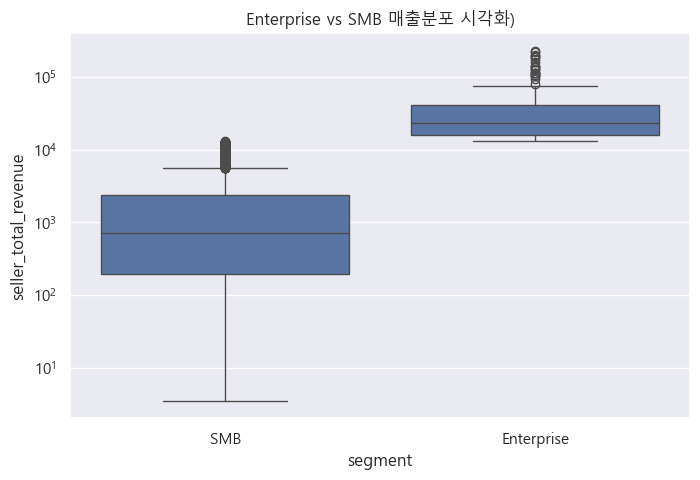

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df.drop_duplicates("seller_id"), x="segment", y="seller_total_revenue")
plt.yscale("log")
plt.title("Enterprise vs SMB 매출분포 시각화)")
plt.show()

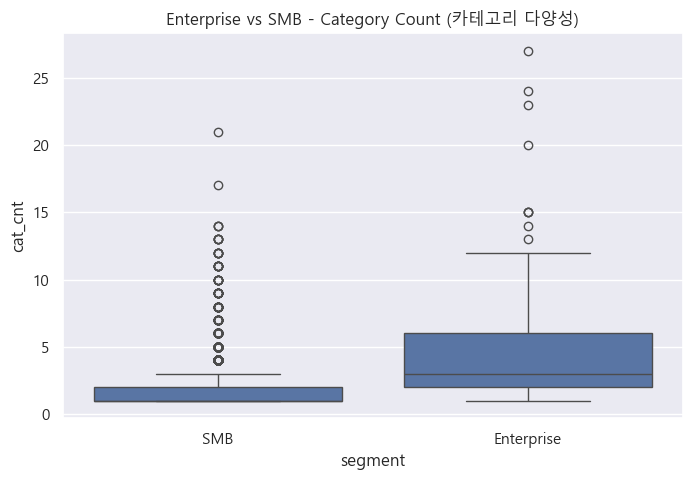

In [18]:
cat_cnt = df.groupby("seller_id")["product_category_name_english"].nunique().reset_index()
cat_cnt.columns = ["seller_id", "cat_cnt"]

cat_cnt = cat_cnt.merge(df[["seller_id", "segment"]].drop_duplicates(), on="seller_id")

plt.figure(figsize=(8,5))
sns.boxplot(data=cat_cnt, x="segment", y="cat_cnt")
plt.title("Enterprise vs SMB - Category Count (카테고리 다양성)")
plt.show()

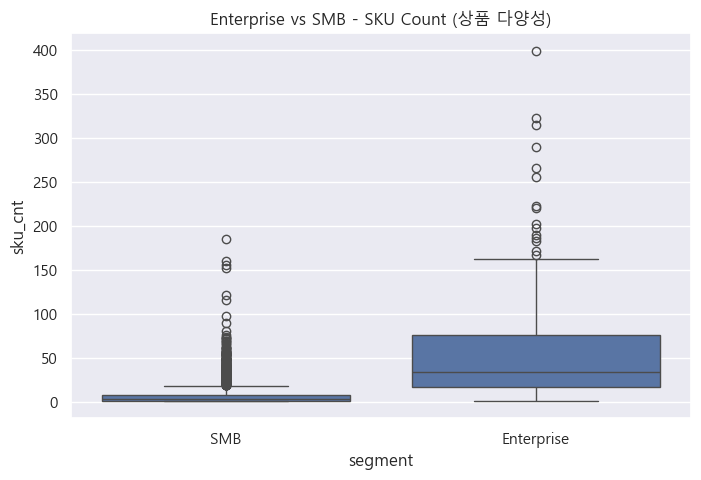

In [19]:
sku_cnt = df.groupby("seller_id")["product_id"].nunique().reset_index()
sku_cnt.columns = ["seller_id", "sku_cnt"]

sku_cnt = sku_cnt.merge(df[["seller_id", "segment"]].drop_duplicates(), on="seller_id")

plt.figure(figsize=(8,5))
sns.boxplot(data=sku_cnt, x="segment", y="sku_cnt")
plt.title("Enterprise vs SMB - SKU Count (상품 다양성)")
plt.show()

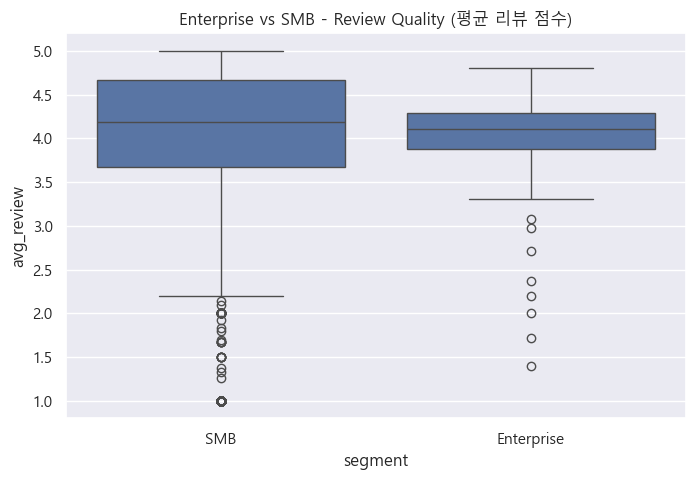

In [20]:
review_mean = df.groupby("seller_id")["review_score"].mean().reset_index()
review_mean.columns = ["seller_id", "avg_review"]

review_mean = review_mean.merge(df[["seller_id", "segment"]].drop_duplicates(), on="seller_id")

plt.figure(figsize=(8,5))
sns.boxplot(data=review_mean, x="segment", y="avg_review")
plt.title("Enterprise vs SMB - Review Quality (평균 리뷰 점수)")
plt.show()

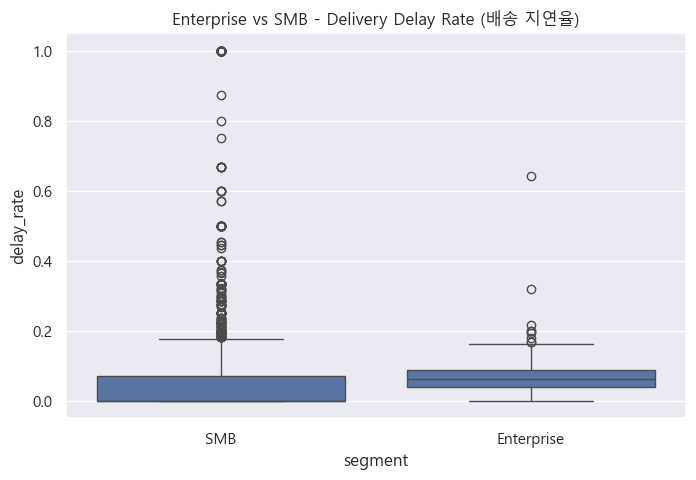

In [21]:
delay_rate = df.groupby("seller_id")["is_delayed"].mean().reset_index()
delay_rate.columns = ["seller_id", "delay_rate"]

delay_rate = delay_rate.merge(df[["seller_id", "segment"]].drop_duplicates(), on="seller_id")

plt.figure(figsize=(8,5))
sns.boxplot(data=delay_rate, x="segment", y="delay_rate")
plt.title("Enterprise vs SMB - Delivery Delay Rate (배송 지연율)")
plt.show()

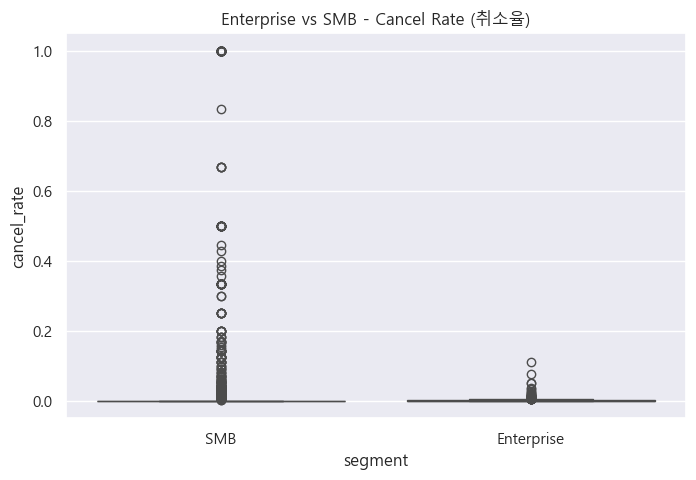

In [22]:
cancel_rate = df.groupby("seller_id")["is_canceled"].mean().reset_index()
cancel_rate.columns = ["seller_id", "cancel_rate"]

cancel_rate = cancel_rate.merge(df[["seller_id", "segment"]].drop_duplicates(), on="seller_id")

plt.figure(figsize=(8,5))
sns.boxplot(data=cancel_rate, x="segment", y="cancel_rate")
plt.title("Enterprise vs SMB - Cancel Rate (취소율)")
plt.show()